# Recalculate Forces with Area Correction

## Problem Description

The simulations were run with `divideNeumannBoundaryConditionValuesByTotalArea = True`, which means:
- The force values (0, 3, 6, ... 31 N) specified in the configuration were **total forces**
- These forces were automatically divided by the top surface area to get the traction (stress)
- **Result**: `traction = F_total / A_top`

## Geometry

The muscle is a cuboid with dimensions `[b, a, a]` where:
- `b = muscle_extent_y` (length in y-direction, varies across simulations)
- `a` is calculated from the fixed volume: `a = sqrt(Volume / b)`
- Top surface area: `A_top = a² = Volume / b`

## Issue

Different combinations of (Volume, muscle_extent_y) result in different cross-sectional areas:
- Same volume but different `b` → different `a` → different `A_top`
- With `divideNeumannBoundaryConditionValuesByTotalArea = True`, the same nominal force F gets divided by different areas
- **This means different geometric configurations experienced different tractions (stress) even with the same nominal force!**

## Calculation

For each configuration, the **effective traction** (force per unit area) applied was:

$$\text{traction} = \frac{F_{\text{total}}}{A_{\text{top}}} = \frac{F_{\text{total}}}{\text{Volume} / b} = \frac{F_{\text{total}} \cdot b}{\text{Volume}}$$

where:
- `F_total` = nominal force from folder name (0, 3, 6, ..., 31 N)
- `b = muscle_extent_y` (cm)
- `Volume` (cm³)

## Idea
The rescaled force is greatest at the smallest surface area (largest b) and becomes smaller as b becomes smaller (surface area becomes larger). This is physically correct: with a larger area, the same total force is distributed over more area, resulting in less stress, which corresponds to a smaller equivalent force at the baseline geometry.

# Output

1. **Effective traction** [N/cm²]: The actual stress applied to the top surface
2. **Equivalent force if divideByArea=False**: If we had set the flag to False, what force value would produce the same physical effect?
   - With flag=False, the specified value is interpreted as traction directly
   - So: `F_equivalent = traction = F_total * b / Volume`


In [105]:
import pandas as pd
import numpy as np
from pathlib import Path

In [106]:
# Load the original ROM data
input_file = 'rom_data_all_combinations.csv'
output_file = 'rom_data_area_corrected.csv'

if not Path(input_file).exists():
    raise FileNotFoundError(f"Please run extract_rom_data.ipynb first to generate {input_file}")

df = pd.read_csv(input_file)
print(f"Loaded {len(df)} rows from {input_file}")
df.head()

Loaded 5040 rows from rom_data_all_combinations.csv


,folder_name,force_N,muscle_extent_y_cm,volume_cm3,am_cm_inv,rho_1e4_kg_cm3,z_max_cm,z_min_cm,rom_cm
0,F00_y32.69_Vol421.6_Am450_rho10.493,0.0,32.69,421.6,450.0,10.493,32.69,29.390991,3.299010
1,F00_y32.69_Vol421.6_Am450_rho10.534,0.0,32.69,421.6,450.0,10.534,32.69,29.392965,3.297035
2,F00_y32.69_Vol421.6_Am450_rho10.575,0.0,32.69,421.6,450.0,10.575,32.69,29.394968,3.295032
3,F00_y32.69_Vol421.6_Am450_rho10.616,0.0,32.69,421.6,450.0,10.616,32.69,29.396904,3.293096
4,F00_y32.69_Vol421.6_Am500_rho10.493,0.0,32.69,421.6,500.0,10.493,32.69,29.383631,3.306369


In [107]:
# Calculate geometric properties
# Volume = b * a * a, where b = muscle_extent_y
# Therefore: a = sqrt(Volume / b)
# Top surface area: A_top = a² = Volume / b

df['cross_sectional_length_a_cm'] = np.sqrt(df['volume_cm3'] / df['muscle_extent_y_cm'])
df['top_surface_area_cm2'] = df['volume_cm3'] / df['muscle_extent_y_cm']

# Alternative calculation (should be the same):
df['top_surface_area_check_cm2'] = df['cross_sectional_length_a_cm'] ** 2

# Verify they match
print("Verification of area calculation:")
print(f"Max difference: {(df['top_surface_area_cm2'] - df['top_surface_area_check_cm2']).abs().max():.10f} cm²")

# Remove check column
df.drop('top_surface_area_check_cm2', axis=1, inplace=True)

print("\nGeometric properties calculated:")
print(df[['muscle_extent_y_cm', 'volume_cm3', 'cross_sectional_length_a_cm', 'top_surface_area_cm2']].describe())

Verification of area calculation:
Max difference: 0.0000000000 cm²

Geometric properties calculated:
       muscle_extent_y_cm   volume_cm3  cross_sectional_length_a_cm  \
count         5040.000000  5040.000000                  5040.000000   
mean            33.746000   575.314286                     4.110677   
std              0.790359   110.016596                     0.400053   
min             32.690000   421.600000                     3.472182   
25%             33.190000   455.900000                     3.706220   
50%             33.690000   573.500000                     4.125876   
75%             34.190000   691.200000                     4.496269   
max             34.970000   738.000000                     4.751390   

       top_surface_area_cm2  
count           5040.000000  
mean              17.057678  
std                3.286941  
min               12.056048  
25%               13.736065  
50%               17.022855  
75%               20.216438  
max               2

In [108]:
# Calculate effective traction
# 
# With divideNeumannBoundaryConditionValuesByTotalArea = True:
#   - force_N is a total force
#   - traction = force_N / top_surface_area_cm2
#
# Different geometries have different areas, so the same force_N 
# produces different traction (stress)

df['effective_traction_N_cm2'] = df['force_N'] / df['top_surface_area_cm2']

print("\nEffective traction calculated:")
print(df[['force_N', 'top_surface_area_cm2', 'effective_traction_N_cm2']].describe())


Effective traction calculated:
           force_N  top_surface_area_cm2  effective_traction_N_cm2
count  5040.000000           5040.000000               5040.000000
mean     16.333333             17.057678                  0.994907
std      10.103257              3.286941                  0.657328
min       0.000000             12.056048                  0.000000
25%       8.250000             13.736065                  0.442208
50%      16.500000             17.022855                  0.963166
75%      24.750000             20.216438                  1.464109
max      31.000000             22.575711                  2.571324


In [109]:
# RESCALE FORCES TO MINIMUM AREA (BASELINE)
# ==========================================
# To make forces comparable across different geometries, we rescale them
# to the minimum cross-sectional area (smallest geometry as baseline).
#
# Strategy: Use the minimum area as reference
# Then calculate what the equivalent total force would be at that reference area
# for the same traction.
#
# Formula: F_rescaled = traction × A_min = (F_original / A_original) × A_min

# Choose reference area - using the minimum area as baseline
reference_area_cm2 = df['top_surface_area_cm2'].min()

print("="*80)
print("FORCE RESCALING TO MINIMUM AREA (BASELINE)")
print("="*80)
print(f"\nReference area (minimum): {reference_area_cm2:.4f} cm²")
print(f"Maximum area in dataset: {df['top_surface_area_cm2'].max():.4f} cm²")
print(f"Mean area in dataset: {df['top_surface_area_cm2'].mean():.4f} cm²")

# Calculate rescaled force to minimum area (baseline)
df['force_rescaled_N'] = df['effective_traction_N_cm2'] * reference_area_cm2

print(f"\nOriginal force range: {df['force_N'].min():.1f} - {df['force_N'].max():.1f} N")
print(f"Rescaled force range (to min area): {df['force_rescaled_N'].min():.4f} - {df['force_rescaled_N'].max():.4f} N")

print("\nRescaled forces calculated:")
print(df[['force_N', 'top_surface_area_cm2', 'effective_traction_N_cm2', 'force_rescaled_N']].describe())

FORCE RESCALING TO MINIMUM AREA (BASELINE)

Reference area (minimum): 12.0560 cm²
Maximum area in dataset: 22.5757 cm²
Mean area in dataset: 17.0577 cm²

Original force range: 0.0 - 31.0 N
Rescaled force range (to min area): 0.0000 - 31.0000 N

Rescaled forces calculated:
           force_N  top_surface_area_cm2  effective_traction_N_cm2  \
count  5040.000000           5040.000000               5040.000000   
mean     16.333333             17.057678                  0.994907   
std      10.103257              3.286941                  0.657328   
min       0.000000             12.056048                  0.000000   
25%       8.250000             13.736065                  0.442208   
50%      16.500000             17.022855                  0.963166   
75%      24.750000             20.216438                  1.464109   
max      31.000000             22.575711                  2.571324   

       force_rescaled_N  
count       5040.000000  
mean          11.994648  
std            7.9

In [110]:
# Show examples for different geometries with same nominal force
print("\n" + "="*80)
print("EXAMPLE: How force rescaling works for same nominal force (e.g., 15N)")
print("="*80)

example_force = 15.0
examples = df[df['force_N'] == example_force].copy()

if len(examples) > 0:
    examples = examples.sort_values(['volume_cm3', 'muscle_extent_y_cm'])
    print(f"\nNominal force: {example_force} N\n")
    print(examples[['volume_cm3', 'muscle_extent_y_cm', 'top_surface_area_cm2', 
                    'effective_traction_N_cm2', 'force_rescaled_N']].to_string(index=False))
    
    print(f"\nTraction range: {examples['effective_traction_N_cm2'].min():.6f} to {examples['effective_traction_N_cm2'].max():.6f} N/cm²")
    print(f"Rescaled force range: {examples['force_rescaled_N'].min():.4f} to {examples['force_rescaled_N'].max():.4f} N")
else:
    print(f"No data found for force = {example_force} N")


EXAMPLE: How force rescaling works for same nominal force (e.g., 15N)

Nominal force: 15.0 N

 volume_cm3  muscle_extent_y_cm  top_surface_area_cm2  effective_traction_N_cm2  force_rescaled_N
      421.6               32.69             12.896910                  1.163069         14.022019
      421.6               32.69             12.896910                  1.163069         14.022019
      421.6               32.69             12.896910                  1.163069         14.022019
      421.6               32.69             12.896910                  1.163069         14.022019
      421.6               32.69             12.896910                  1.163069         14.022019
      421.6               32.69             12.896910                  1.163069         14.022019
      421.6               32.69             12.896910                  1.163069         14.022019
      421.6               32.69             12.896910                  1.163069         14.022019
      421.6            

In [111]:
# Reorder columns for the output CSV
column_order = [
    'folder_name',
    'force_N',
    'muscle_extent_y_cm',
    'volume_cm3',
    'am_cm_inv',
    'rho_1e4_kg_cm3',
    'cross_sectional_length_a_cm',
    'top_surface_area_cm2',
    'effective_traction_N_cm2',
    'force_rescaled_N',
    'z_max_cm',
    'z_min_cm',
    'rom_cm'
]

df_output = df[column_order].copy()

print("\nFinal DataFrame structure:")
print(df_output.head(10))


Final DataFrame structure:
                           folder_name  force_N  muscle_extent_y_cm  \
0  F00_y32.69_Vol421.6_Am450_rho10.493      0.0               32.69   
1  F00_y32.69_Vol421.6_Am450_rho10.534      0.0               32.69   
2  F00_y32.69_Vol421.6_Am450_rho10.575      0.0               32.69   
3  F00_y32.69_Vol421.6_Am450_rho10.616      0.0               32.69   
4  F00_y32.69_Vol421.6_Am500_rho10.493      0.0               32.69   
5  F00_y32.69_Vol421.6_Am500_rho10.534      0.0               32.69   
6  F00_y32.69_Vol421.6_Am500_rho10.575      0.0               32.69   
7  F00_y32.69_Vol421.6_Am500_rho10.616      0.0               32.69   
8  F00_y32.69_Vol421.6_Am550_rho10.493      0.0               32.69   
9  F00_y32.69_Vol421.6_Am550_rho10.534      0.0               32.69   

   volume_cm3  am_cm_inv  rho_1e4_kg_cm3  cross_sectional_length_a_cm  \
0       421.6      450.0          10.493                     3.591227   
1       421.6      450.0          10.534    

In [112]:
# Save to CSV
df_output.to_csv(output_file, index=False)
print(f"\nData saved to: {output_file}")
print(f"Absolute path: {Path(output_file).absolute()}")
print(f"\nTotal rows: {len(df_output)}")


Data saved to: rom_data_area_corrected.csv
Absolute path: /Users/canis/Library/CloudStorage/OneDrive-Persönlich/work/SdV/natwissKolleg/results/final_results/results_for_paper/da_4/rom_data_area_corrected.csv

Total rows: 5040


In [113]:
# Summary statistics
print("\n" + "="*80)
print("SUMMARY: Force and Traction Statistics")
print("="*80)

print("\nNominal forces (as specified in configuration):")
print(f"  Range: {df_output['force_N'].min():.1f} - {df_output['force_N'].max():.1f} N")
print(f"  Unique values: {sorted(df_output['force_N'].unique())}")

print("\nTop surface areas:")
print(f"  Range: {df_output['top_surface_area_cm2'].min():.2f} - {df_output['top_surface_area_cm2'].max():.2f} cm²")
print(f"  Mean: {df_output['top_surface_area_cm2'].mean():.2f} cm²")

print("\nEffective tractions (actual stress applied):")
print(f"  Range: {df_output['effective_traction_N_cm2'].min():.6f} - {df_output['effective_traction_N_cm2'].max():.6f} N/cm²")
print(f"  Mean: {df_output['effective_traction_N_cm2'].mean():.6f} N/cm²")

print("\nRescaled forces (normalized to minimum area):")
print(f"  Range: {df_output['force_rescaled_N'].min():.4f} - {df_output['force_rescaled_N'].max():.4f} N")
print(f"  Mean: {df_output['force_rescaled_N'].mean():.4f} N")

print("\nRange of Motion:")
print(f"  z_max: {df_output['z_max_cm'].min():.4f} - {df_output['z_max_cm'].max():.4f} cm")
print(f"  z_min: {df_output['z_min_cm'].min():.4f} - {df_output['z_min_cm'].max():.4f} cm")
print(f"  ROM: {df_output['rom_cm'].min():.4f} - {df_output['rom_cm'].max():.4f} cm")


SUMMARY: Force and Traction Statistics

Nominal forces (as specified in configuration):
  Range: 0.0 - 31.0 N
  Unique values: [np.float64(0.0), np.float64(3.0), np.float64(6.0), np.float64(9.0), np.float64(12.0), np.float64(15.0), np.float64(18.0), np.float64(21.0), np.float64(24.0), np.float64(27.0), np.float64(30.0), np.float64(31.0)]

Top surface areas:
  Range: 12.06 - 22.58 cm²
  Mean: 17.06 cm²

Effective tractions (actual stress applied):
  Range: 0.000000 - 2.571324 N/cm²
  Mean: 0.994907 N/cm²

Rescaled forces (normalized to minimum area):
  Range: 0.0000 - 31.0000 N
  Mean: 11.9946 N

Range of Motion:
  z_max: 32.6900 - 49.9404 cm
  z_min: 29.3763 - 48.9743 cm
  ROM: 0.0000 - 3.9547 cm


# Visualization: ROM vs Rescaled Force

In [114]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

/var/folders/qg/82ll9gvd1pd4329hnkdpf8ch0000gn/T/ipykernel_75078/1744031313.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', len(volumes))


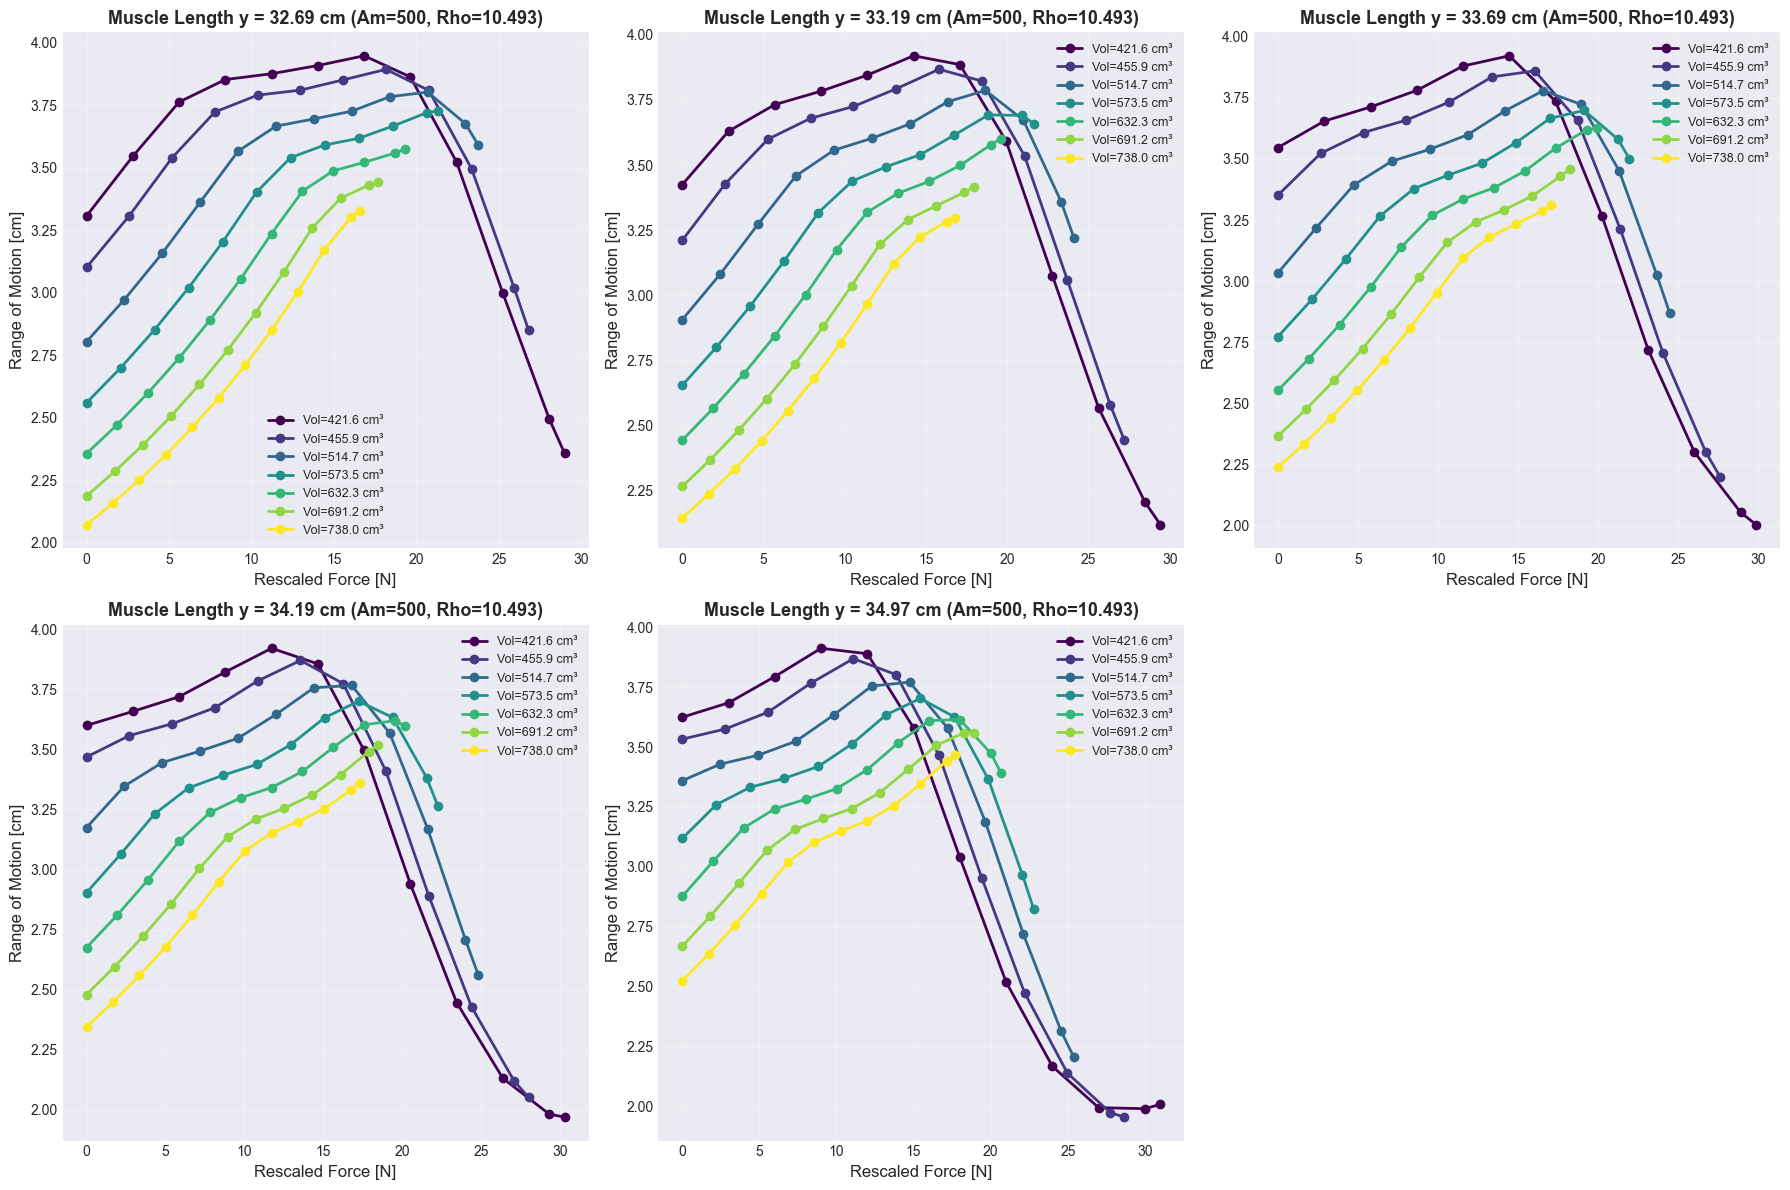

Saved plot: rom_vs_force_by_muscle_length.png


In [115]:
# Plot 1: ROM vs Rescaled Force for different volumes (fixed muscle_extent_y)
# Each volume gets a different color
# Fixed Am = 500 and Rho = 10.493 for simplification

# Filter data for fixed Am and Rho
df_plot = df_output[(df_output['am_cm_inv'] == 500) & (df_output['rho_1e4_kg_cm3'] == 10.493)]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Get unique muscle_extent_y values
muscle_y_values = sorted(df_plot['muscle_extent_y_cm'].unique())

# Get unique volumes
volumes = sorted(df_plot['volume_cm3'].unique())

# Create a colormap for volumes
cmap = cm.get_cmap('viridis', len(volumes))
colors = {vol: cmap(i) for i, vol in enumerate(volumes)}

for idx, muscle_y in enumerate(muscle_y_values):
    if idx >= len(axes):
        break
    
    ax = axes[idx]
    
    # Filter data for this muscle_extent_y
    data_y = df_plot[df_plot['muscle_extent_y_cm'] == muscle_y]
    
    # Plot each volume separately
    for volume in volumes:
        data_vol = data_y[data_y['volume_cm3'] == volume]
        
        if len(data_vol) > 0:
            data_vol = data_vol.sort_values('force_rescaled_N')
            
            ax.plot(data_vol['force_rescaled_N'], data_vol['rom_cm'], 
                   marker='o', linestyle='-', color=colors[volume],
                   label=f'Vol={volume:.1f} cm³', linewidth=2, markersize=6)
    
    ax.set_xlabel('Rescaled Force [N]', fontsize=12)
    ax.set_ylabel('Range of Motion [cm]', fontsize=12)
    ax.set_title(f'Muscle Length y = {muscle_y:.2f} cm (Am=500, Rho=10.493)', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc='best')

# Hide unused subplots
for idx in range(len(muscle_y_values), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig('rom_vs_force_by_muscle_length.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved plot: rom_vs_force_by_muscle_length.png")

/var/folders/qg/82ll9gvd1pd4329hnkdpf8ch0000gn/T/ipykernel_75078/1949732138.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_y = cm.get_cmap('plasma', len(muscle_y_values))


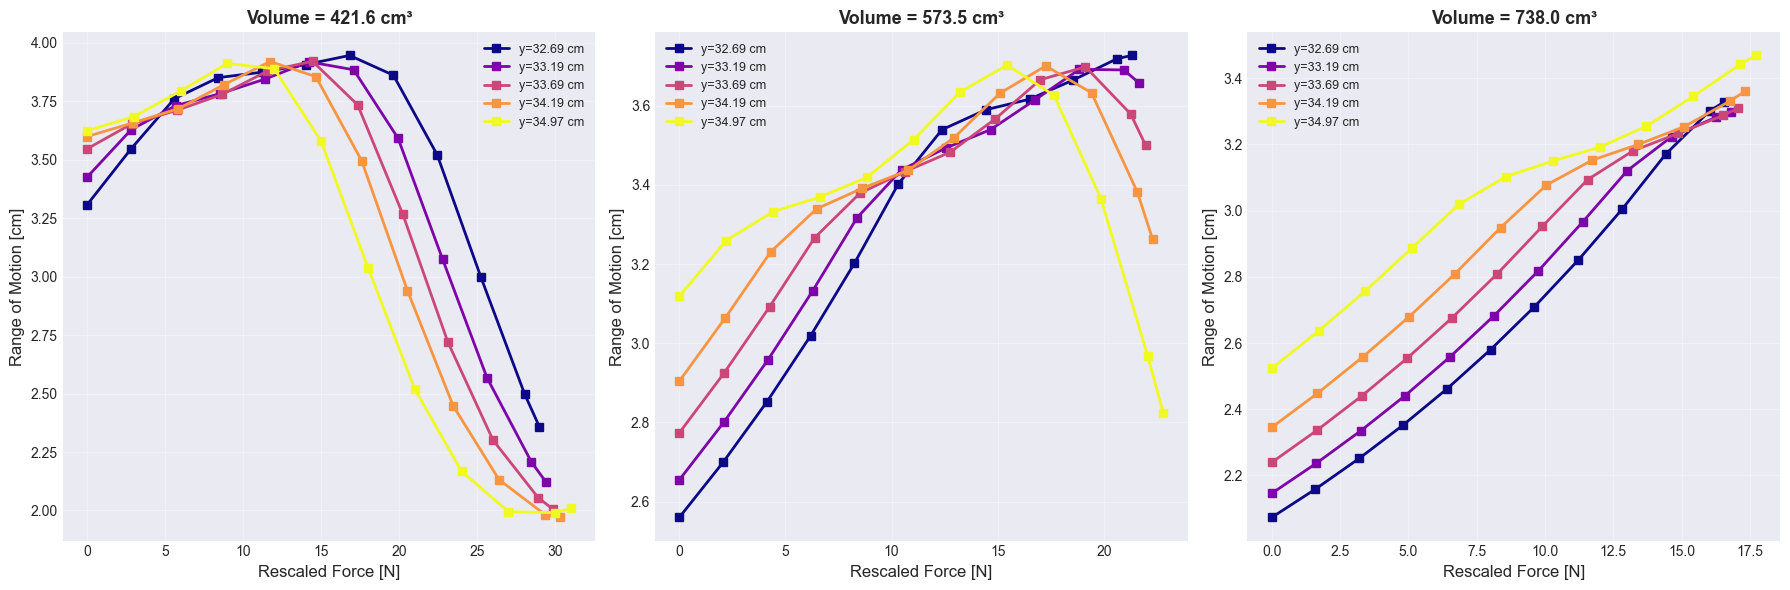

Saved plot: rom_vs_force_by_volume.png


In [116]:
# Plot 2: ROM vs Rescaled Force for different muscle lengths (fixed volume)
# Each muscle_extent_y gets a different color
# Fixed Am = 500 and Rho = 10.493 for simplification
# Only selected volumes: 421.6, 573.5, 738.0

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.flatten()

# Select only specific volumes
selected_volumes = [421.6, 573.5, 738.0]

# Create a colormap for muscle_extent_y values
cmap_y = cm.get_cmap('plasma', len(muscle_y_values))
colors_y = {y: cmap_y(i) for i, y in enumerate(muscle_y_values)}

for idx, volume in enumerate(selected_volumes):
    ax = axes[idx]
    
    # Filter data for this volume
    data_vol = df_plot[df_plot['volume_cm3'] == volume]
    
    # Plot each muscle_extent_y separately
    for muscle_y in muscle_y_values:
        data_y = data_vol[data_vol['muscle_extent_y_cm'] == muscle_y]
        
        if len(data_y) > 0:
            data_y = data_y.sort_values('force_rescaled_N')
            
            ax.plot(data_y['force_rescaled_N'], data_y['rom_cm'], 
                   marker='s', linestyle='-', color=colors_y[muscle_y],
                   label=f'y={muscle_y:.2f} cm', linewidth=2, markersize=6)
    
    ax.set_xlabel('Rescaled Force [N]', fontsize=12)
    ax.set_ylabel('Range of Motion [cm]', fontsize=12)
    ax.set_title(f'Volume = {volume:.1f} cm³', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc='best')

plt.tight_layout()
plt.savefig('rom_vs_force_by_volume.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved plot: rom_vs_force_by_volume.png")

/var/folders/qg/82ll9gvd1pd4329hnkdpf8ch0000gn/T/ipykernel_75078/2657958854.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_vol = cm.get_cmap('viridis', len(volumes))


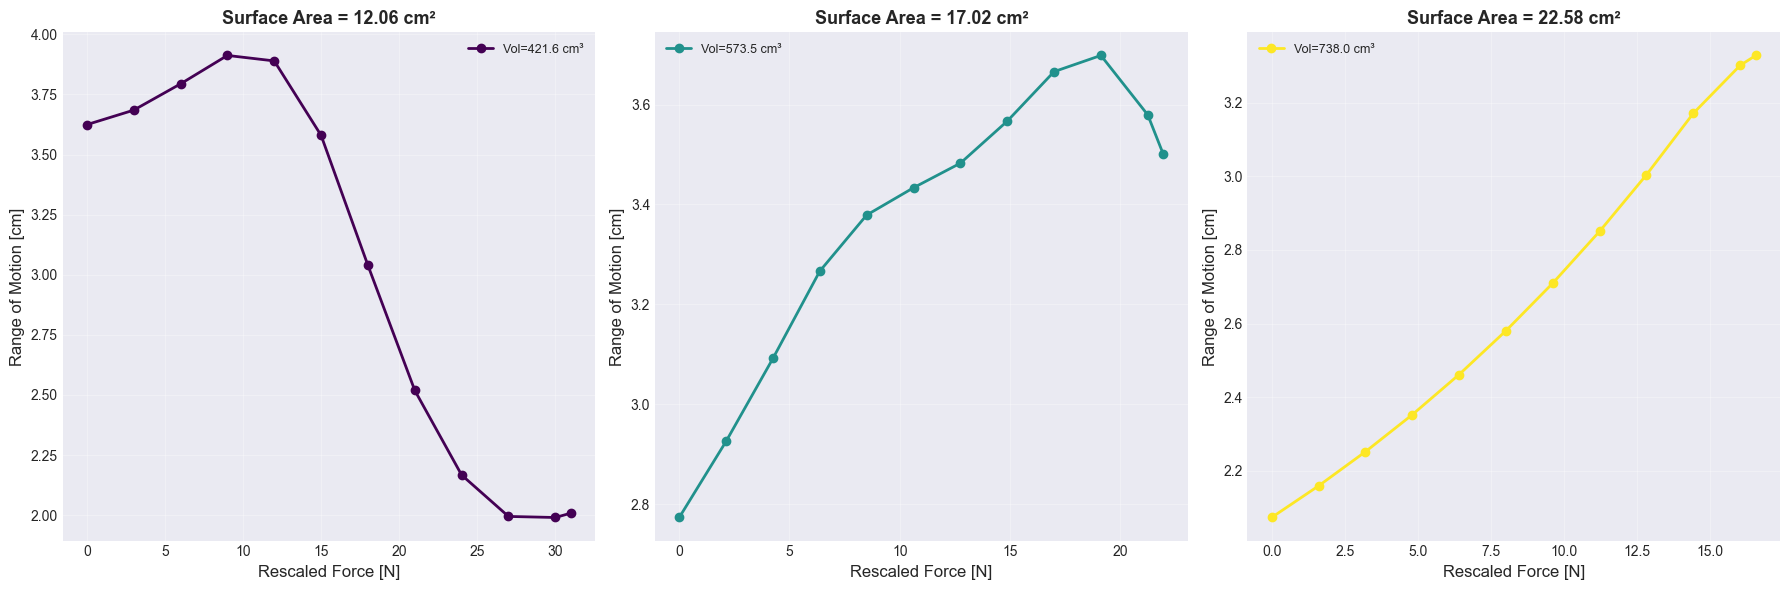

Saved plot: rom_vs_force_by_surface_area.png


In [117]:
# Plot 2b: ROM vs Rescaled Force for different volumes (fixed surface area)
# Each volume gets a different color
# Fixed Am = 500 and Rho = 10.493 for simplification
# Only selected surface areas

# Get unique surface areas and select 3 representative ones
all_areas = sorted(df_plot['top_surface_area_cm2'].unique())
# Select min, middle, and max area
selected_areas = [all_areas[0], all_areas[len(all_areas)//2], all_areas[-1]]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.flatten()

# Create a colormap for volumes
cmap_vol = cm.get_cmap('viridis', len(volumes))
colors_vol = {vol: cmap_vol(i) for i, vol in enumerate(volumes)}

for idx, area in enumerate(selected_areas):
    ax = axes[idx]
    
    # Filter data for this surface area (with small tolerance for floating point comparison)
    data_area = df_plot[np.abs(df_plot['top_surface_area_cm2'] - area) < 0.01]
    
    # Plot each volume separately
    for volume in volumes:
        data_vol = data_area[data_area['volume_cm3'] == volume]
        
        if len(data_vol) > 0:
            data_vol = data_vol.sort_values('force_rescaled_N')
            
            ax.plot(data_vol['force_rescaled_N'], data_vol['rom_cm'], 
                   marker='o', linestyle='-', color=colors_vol[volume],
                   label=f'Vol={volume:.1f} cm³', linewidth=2, markersize=6)
    
    ax.set_xlabel('Rescaled Force [N]', fontsize=12)
    ax.set_ylabel('Range of Motion [cm]', fontsize=12)
    ax.set_title(f'Surface Area = {area:.2f} cm²', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc='best')

plt.tight_layout()
plt.savefig('rom_vs_force_by_surface_area.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved plot: rom_vs_force_by_surface_area.png")

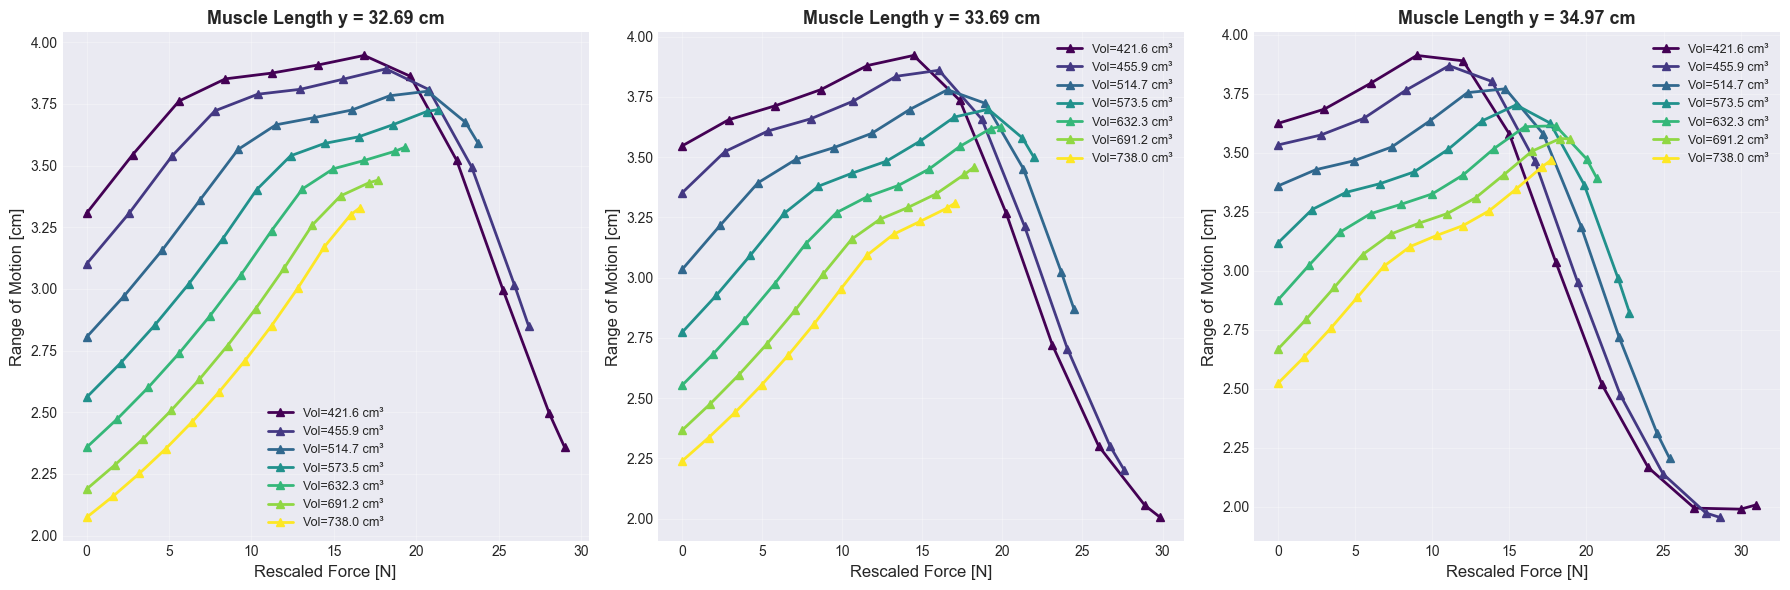

Saved plot: rom_vs_force_by_muscle_length.png


In [118]:
# Plot 2c: ROM vs Rescaled Force for different volumes (fixed muscle length)
# Each volume gets a different color
# Fixed Am = 500 and Rho = 10.493 for simplification
# Only selected muscle lengths

# Select 3 representative muscle lengths (min, middle, max)
selected_muscle_y = [muscle_y_values[0], muscle_y_values[len(muscle_y_values)//2], muscle_y_values[-1]]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.flatten()

for idx, muscle_y in enumerate(selected_muscle_y):
    ax = axes[idx]
    
    # Filter data for this muscle_extent_y
    data_y = df_plot[df_plot['muscle_extent_y_cm'] == muscle_y]
    
    # Plot each volume separately
    for volume in volumes:
        data_vol = data_y[data_y['volume_cm3'] == volume]
        
        if len(data_vol) > 0:
            data_vol = data_vol.sort_values('force_rescaled_N')
            
            ax.plot(data_vol['force_rescaled_N'], data_vol['rom_cm'], 
                   marker='^', linestyle='-', color=colors_vol[volume],
                   label=f'Vol={volume:.1f} cm³', linewidth=2, markersize=6)
    
    ax.set_xlabel('Rescaled Force [N]', fontsize=12)
    ax.set_ylabel('Range of Motion [cm]', fontsize=12)
    ax.set_title(f'Muscle Length y = {muscle_y:.2f} cm', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc='best')

plt.tight_layout()
plt.savefig('rom_vs_force_by_muscle_length.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved plot: rom_vs_force_by_muscle_length.png")

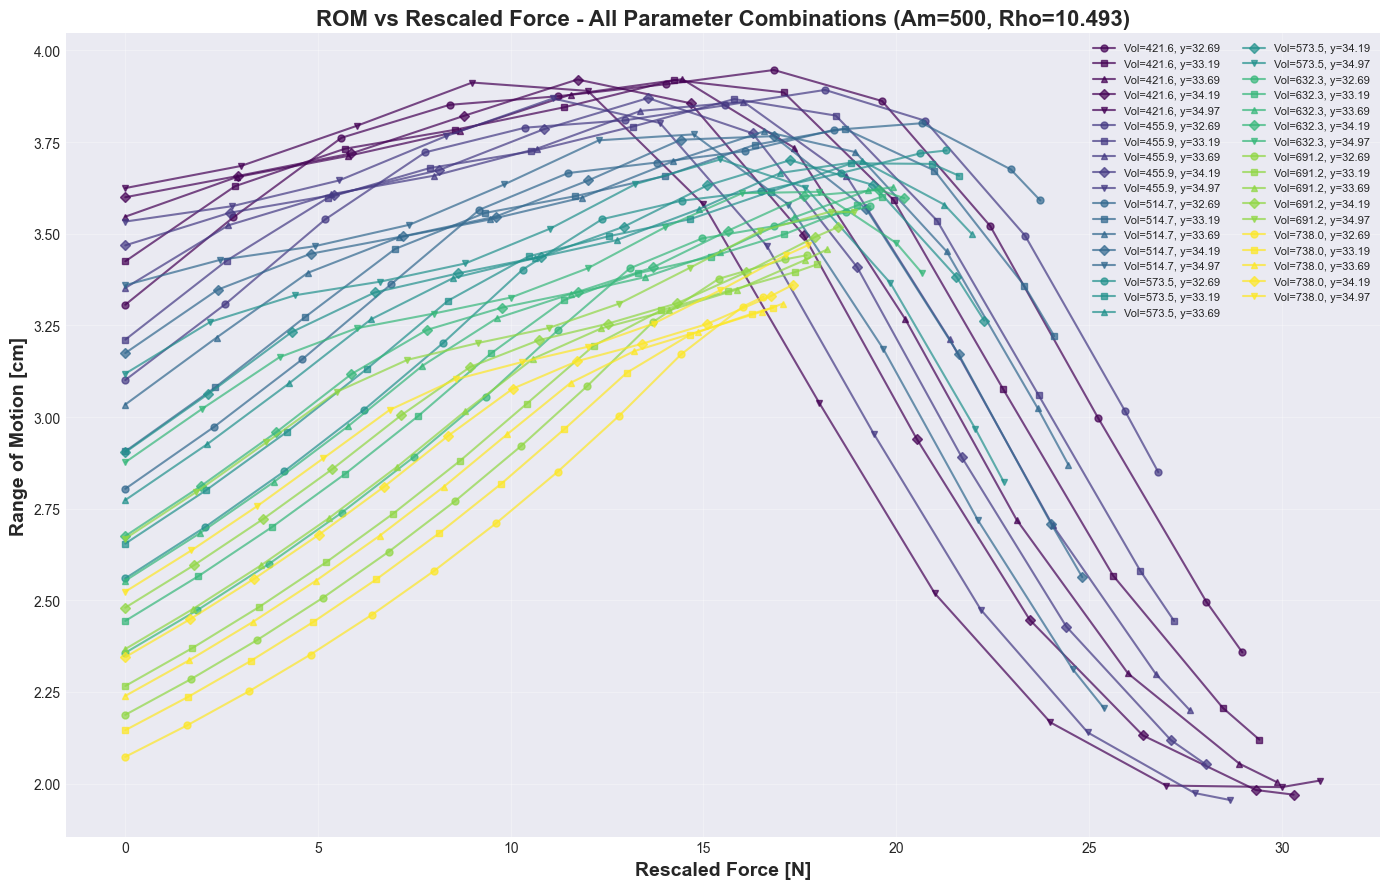

Saved plot: rom_vs_force_all_combinations.png


In [119]:
# Plot 3: Comprehensive view - ROM vs Force with all data points
# Color by volume, marker style by muscle_extent_y
# Fixed Am = 500 and Rho = 10.493 for simplification

fig, ax = plt.subplots(figsize=(14, 9))

# Define marker styles for different muscle_extent_y values
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p']
marker_map = {y: markers[i % len(markers)] for i, y in enumerate(muscle_y_values)}

# Plot all combinations
for volume in volumes:
    for muscle_y in muscle_y_values:
        data = df_plot[(df_plot['volume_cm3'] == volume) & 
                        (df_plot['muscle_extent_y_cm'] == muscle_y)]
        
        if len(data) > 0:
            data = data.sort_values('force_rescaled_N')
            
            ax.plot(data['force_rescaled_N'], data['rom_cm'],
                   marker=marker_map[muscle_y], linestyle='-', 
                   color=colors[volume], alpha=0.7,
                   label=f'Vol={volume:.1f}, y={muscle_y:.2f}',
                   linewidth=1.5, markersize=5)

ax.set_xlabel('Rescaled Force [N]', fontsize=14, fontweight='bold')
ax.set_ylabel('Range of Motion [cm]', fontsize=14, fontweight='bold')
ax.set_title('ROM vs Rescaled Force - All Parameter Combinations (Am=500, Rho=10.493)', fontsize=16, fontweight='bold')
ax.grid(True, alpha=0.3)

# Create custom legend with fewer entries for clarity
# Show just a few representative combinations
ax.legend(fontsize=8, loc='best', ncol=2, framealpha=0.9)

plt.tight_layout()
plt.savefig('rom_vs_force_all_combinations.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved plot: rom_vs_force_all_combinations.png")

- bei fixem Volumen, je größer die Surface area (a^2 größer, also b = länge vom Muskel kleiner), desto größer die range of motion und desto mehr force muss angewandt werden.
- bei fixer Länge, je größer das Volumen (je dicker der Muskel), desto geringer die ROM und desto mehr force muss auch angewant werden.